In [1]:
import pandas as pd
print(pd.__version__)

3.0.5


In [2]:
import pandas as pd


DATA_PATH = r"C:\Users\patil\SIH-2026\ml\dataset\raw\sih_fence_raw_dataset.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Total rows: {len(df_raw)}")
print(f"Total columns: {len(df_raw.columns)}")

df_raw.head()

Total rows: 26
Total columns: 10


,sample_id,zone1_voltage_v,zone2_voltage_v,zone3_voltage_v,bus_voltage_v,current_ma,power_mw,condition,fault_zone,data_quality
0,1,1.49,1.47,1.42,3.328,121.4,406.0,NORMAL,NONE,MEASURED
1,2,1.51,1.47,1.27,3.356,103.8,348.0,NORMAL,NONE,MEASURED
2,3,1.48,3.30,1.29,3.276,88.2,294.0,OPEN_CUT,ZONE2,MEASURED
3,4,1.49,3.30,1.28,3.296,85.5,404.0,OPEN_CUT,ZONE2,MEASURED
4,5,1.49,3.30,1.26,3.308,125.7,416.0,OPEN_CUT,ZONE2,MEASURED


In [3]:
EXPECTED_TOTAL_ROWS = 26

if len(df_raw) == EXPECTED_TOTAL_ROWS:
    print(f"✅ Row count matches documentation: {len(df_raw)} rows")
else:
    print(f"⚠️ WARNING: Expected {EXPECTED_TOTAL_ROWS} rows, found {len(df_raw)}")

✅ Row count matches documentation: 26 rows


In [4]:
EXPECTED_QUALITY_COUNTS = {
    "MEASURED": 20,
    "IMPUTED_BUS_VOLTAGE": 6,
}

actual_quality_counts = df_raw["data_quality"].value_counts()
print("Actual data_quality counts:")
print(actual_quality_counts)

print("\nComparison against documentation:")
for quality_label, expected_count in EXPECTED_QUALITY_COUNTS.items():
    actual_count = actual_quality_counts.get(quality_label, 0)
    status = "✅" if actual_count == expected_count else "⚠️ MISMATCH"
    print(f"{quality_label}: expected={expected_count}, actual={actual_count} {status}")

Actual data_quality counts:
data_quality
MEASURED               20
IMPUTED_BUS_VOLTAGE     6
Name: count, dtype: int64

Comparison against documentation:
MEASURED: expected=20, actual=20 ✅
IMPUTED_BUS_VOLTAGE: expected=6, actual=6 ✅


In [5]:
EXPECTED_IMPUTED_IDS = {6, 16, 17, 22, 24, 26}

actual_imputed_ids = set(
    df_raw.loc[df_raw["data_quality"] == "IMPUTED_BUS_VOLTAGE", "sample_id"]
)

print(f"Expected imputed sample_ids: {sorted(EXPECTED_IMPUTED_IDS)}")
print(f"Actual imputed sample_ids:   {sorted(actual_imputed_ids)}")

if actual_imputed_ids == EXPECTED_IMPUTED_IDS:
    print("✅ Imputed sample IDs match documentation exactly")
else:
    missing = EXPECTED_IMPUTED_IDS - actual_imputed_ids
    unexpected = actual_imputed_ids - EXPECTED_IMPUTED_IDS
    print("⚠️ WARNING: Imputed sample IDs do NOT match documentation")
    if missing:
        print(f"   Missing (expected but not found): {sorted(missing)}")
    if unexpected:
        print(f"   Unexpected (found but not documented): {sorted(unexpected)}")

Expected imputed sample_ids: [6, 16, 17, 22, 24, 26]
Actual imputed sample_ids:   [6, 16, 17, 22, 24, 26]
✅ Imputed sample IDs match documentation exactly


In [6]:
df_measured = df_raw[df_raw["data_quality"] == "MEASURED"].copy()
df_imputed = df_raw[df_raw["data_quality"] == "IMPUTED_BUS_VOLTAGE"].copy()

print(f"df_measured shape: {df_measured.shape}")
print(f"df_imputed shape:  {df_imputed.shape}")

df_measured shape: (20, 10)
df_imputed shape:  (6, 10)


In [7]:
print("condition counts in df_measured:")
print(df_measured["condition"].value_counts())

print("\ncondition counts in df_imputed:")
print(df_imputed["condition"].value_counts())

condition counts in df_measured:
condition
OPEN_CUT    9
SHORT       9
NORMAL      2
Name: count, dtype: int64

condition counts in df_imputed:
condition
OPEN_CUT       5
MULTI_FAULT    1
Name: count, dtype: int64


In [8]:
def run_data_quality_gate(df: pd.DataFrame) -> bool:
    """
    Check the raw FENCEGUARD-X dataset against documented expectations.

    Returns True if all checks pass, False if any check fails.
    Does not modify the input DataFrame.
    """
    checks_passed = True

    if len(df) != EXPECTED_TOTAL_ROWS:
        checks_passed = False

    quality_counts = df["data_quality"].value_counts()
    for label, expected in EXPECTED_QUALITY_COUNTS.items():
        if quality_counts.get(label, 0) != expected:
            checks_passed = False

    imputed_ids = set(df.loc[df["data_quality"] == "IMPUTED_BUS_VOLTAGE", "sample_id"])
    if imputed_ids != EXPECTED_IMPUTED_IDS:
        checks_passed = False

    return checks_passed


gate_result = run_data_quality_gate(df_raw)
if gate_result:
    print("✅ DATA QUALITY GATE: PASSED — dataset matches documentation")
else:
    print("⚠️ DATA QUALITY GATE: FAILED — review warnings above before proceeding")

✅ DATA QUALITY GATE: PASSED — dataset matches documentation


In [9]:
# Quick recap of class distribution before visualizing — helps interpret plots
# where some conditions will have very few points (e.g. NORMAL, MULTI_FAULT)
print("condition counts in df_measured (n=20):")
print(df_measured["condition"].value_counts())

condition counts in df_measured (n=20):
condition
OPEN_CUT    9
SHORT       9
NORMAL      2
Name: count, dtype: int64


In [10]:
sensor_columns = [
    "zone1_voltage_v",
    "zone2_voltage_v",
    "zone3_voltage_v",
    "bus_voltage_v",
    "current_ma",
    "power_mw",
]

# .describe() gives count, mean, std, min, max, and quartiles for each column
print("Descriptive statistics (df_measured, MEASURED rows only):")
print(df_measured[sensor_columns].describe())

Descriptive statistics (df_measured, MEASURED rows only):
       zone1_voltage_v  zone2_voltage_v  zone3_voltage_v  bus_voltage_v  \
count        20.000000        20.000000        20.000000      20.000000   
mean          1.547500         1.675000         1.296000       3.233800   
std           1.074576         0.896464         0.888224       0.136947   
min           0.000000         0.000000         0.000000       2.844000   
25%           1.447500         1.237500         1.250000       3.241000   
50%           1.490000         1.470000         1.355000       3.276000   
75%           1.510000         1.802500         1.492500       3.298000   
max           3.300000         3.300000         3.300000       3.356000   

       current_ma    power_mw  
count   20.000000   20.000000  
mean    97.505000  321.400000  
std     13.652009   52.178237  
min     77.700000  236.000000  
25%     88.150000  291.000000  
50%     94.450000  309.000000  
75%    109.225000  361.000000  
max    125

In [11]:
import matplotlib.pyplot as plt

def plot_feature_by_condition(df: pd.DataFrame, feature_column: str, ylabel: str, title: str) -> None:
    """
    Plot a single sensor feature grouped by condition as a strip/scatter plot.

    Each condition is plotted along the x-axis as a category, with individual
    sample values as points on the y-axis. This makes it easy to see whether
    a feature separates cleanly between conditions or overlaps.

    Does not modify the input DataFrame.
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    conditions = df["condition"].unique()
    for condition_name in conditions:
        subset = df[df["condition"] == condition_name]
        # Add a little horizontal jitter isn't needed here since n is small,
        # so we plot each condition at its own x-position with real values on y
        x_positions = [condition_name] * len(subset)
        ax.scatter(x_positions, subset[feature_column], label=condition_name, s=60, alpha=0.8)

    ax.set_xlabel("condition")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

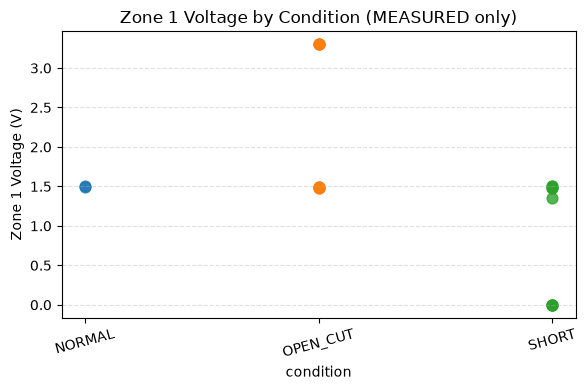

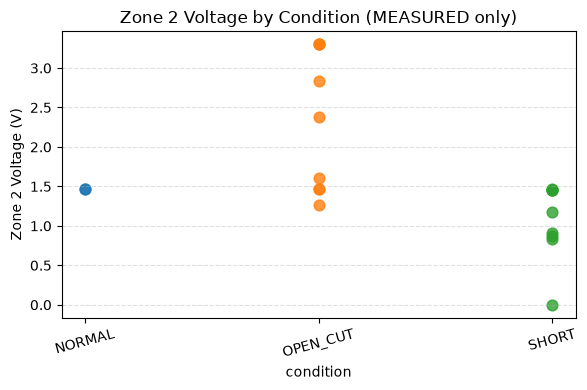

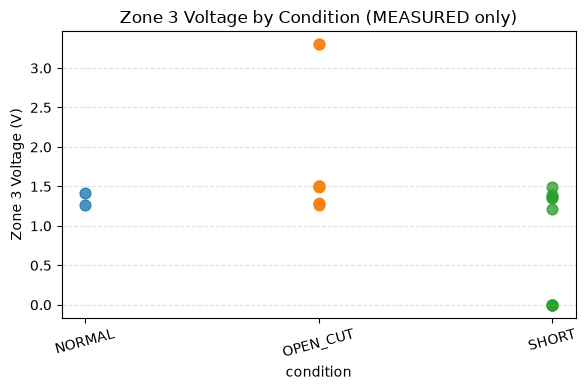

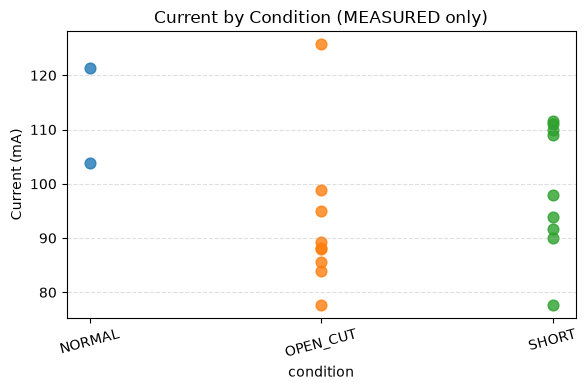

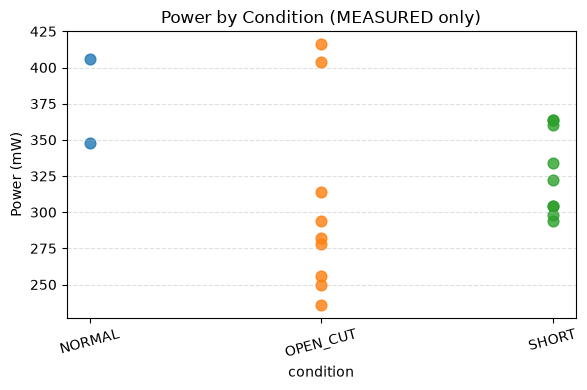

In [12]:
# Zone voltages — expected to show the clearest separation by condition
plot_feature_by_condition(df_measured, "zone1_voltage_v", "Zone 1 Voltage (V)", "Zone 1 Voltage by Condition (MEASURED only)")
plot_feature_by_condition(df_measured, "zone2_voltage_v", "Zone 2 Voltage (V)", "Zone 2 Voltage by Condition (MEASURED only)")
plot_feature_by_condition(df_measured, "zone3_voltage_v", "Zone 3 Voltage (V)", "Zone 3 Voltage by Condition (MEASURED only)")

# Current and power — included to check whether they separate as cleanly as zone voltages, or overlap
plot_feature_by_condition(df_measured, "current_ma", "Current (mA)", "Current by Condition (MEASURED only)")
plot_feature_by_condition(df_measured, "power_mw", "Power (mW)", "Power by Condition (MEASURED only)")

In [13]:
FEATURE_COLUMNS = [
    "zone1_voltage_v",
    "zone2_voltage_v",
    "zone3_voltage_v",
    "bus_voltage_v",
    "current_ma",
    "power_mw",
]
TARGET_COLUMN = "condition"

# Using all 20 MEASURED rows for training — no train/test split, since the
# dataset is too small and class-imbalanced for a meaningful held-out split
X_train = df_measured[FEATURE_COLUMNS]
y_train = df_measured[TARGET_COLUMN]

print(f"X_train shape: {X_train.shape}")
print(f"y_train class distribution:\n{y_train.value_counts()}")

X_train shape: (20, 6)
y_train class distribution:
condition
OPEN_CUT    9
SHORT       9
NORMAL      2
Name: count, dtype: int64


In [14]:
from sklearn.tree import DecisionTreeClassifier

def train_baseline_tree(X: pd.DataFrame, y: pd.Series, max_depth: int = 4) -> DecisionTreeClassifier:
    """
    Train a baseline DecisionTreeClassifier on FENCEGUARD-X MEASURED data.

    IMPORTANT: This is a proof-of-concept baseline trained on only 20
    MEASURED samples with thin/missing class coverage (2 NORMAL, 0
    MULTI_FAULT). It is NOT a validated model. No accuracy, precision,
    recall, or other performance metrics are computed here, because the
    dataset is currently too small for such numbers to be meaningful.

    Does not modify the input DataFrame.
    """
    tree_model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    tree_model.fit(X, y)
    return tree_model


baseline_tree = train_baseline_tree(X_train, y_train, max_depth=4)
print("Baseline decision tree trained (proof-of-concept, n=20, not validated).")

Baseline decision tree trained (proof-of-concept, n=20, not validated).


In [15]:
from sklearn.tree import export_text

tree_rules = export_text(baseline_tree, feature_names=FEATURE_COLUMNS)
print("Learned decision tree rules (proof-of-concept baseline):")
print(tree_rules)

Learned decision tree rules (proof-of-concept baseline):
|--- zone2_voltage_v <= 1.47
|   |--- zone1_voltage_v <= 2.40
|   |   |--- class: SHORT
|   |--- zone1_voltage_v >  2.40
|   |   |--- class: OPEN_CUT
|--- zone2_voltage_v >  1.47
|   |--- bus_voltage_v <= 3.32
|   |   |--- zone1_voltage_v <= 0.74
|   |   |   |--- class: SHORT
|   |   |--- zone1_voltage_v >  0.74
|   |   |   |--- class: OPEN_CUT
|   |--- bus_voltage_v >  3.32
|   |   |--- class: NORMAL



In [16]:
# NOTE: These predictions are a qualitative sanity check on data the model
# never trained on. They are NOT a test-set evaluation and no accuracy is
# calculated, since df_imputed is only 6 rows and was excluded from training
# specifically because bus_voltage_v was reconstructed, not measured.
X_imputed = df_imputed[FEATURE_COLUMNS]
imputed_predictions = baseline_tree.predict(X_imputed)

print("Predictions on df_imputed (qualitative sanity check only):")
for sample_id, actual_condition, predicted_condition in zip(
    df_imputed["sample_id"], df_imputed["condition"], imputed_predictions
):
    match_flag = "✅ matches documented condition" if actual_condition == predicted_condition else "⚠️ differs from documented condition"
    print(f"sample_id={sample_id}: documented={actual_condition}, predicted={predicted_condition}  {match_flag}")

Predictions on df_imputed (qualitative sanity check only):
sample_id=6: documented=OPEN_CUT, predicted=OPEN_CUT  ✅ matches documented condition
sample_id=16: documented=OPEN_CUT, predicted=OPEN_CUT  ✅ matches documented condition
sample_id=17: documented=OPEN_CUT, predicted=OPEN_CUT  ✅ matches documented condition
sample_id=22: documented=OPEN_CUT, predicted=OPEN_CUT  ✅ matches documented condition
sample_id=24: documented=MULTI_FAULT, predicted=OPEN_CUT  ⚠️ differs from documented condition
sample_id=26: documented=OPEN_CUT, predicted=OPEN_CUT  ✅ matches documented condition
